In [15]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import spearmanr

In [16]:
# Load datasets

high_df = pd.read_csv('high_popularity_spotify_data.csv')
low_df = pd.read_csv('low_popularity_spotify_data.csv')

# Source labels
high_df["source_dataset"] = "high"
low_df["source_dataset"] = "low"

df = pd.concat([high_df, low_df], ignore_index=True)

print("Shape before cleaning:", df.shape)
print(df.head())
print(df.columns.tolist())

Shape before cleaning: (4831, 30)
   energy    tempo  danceability playlist_genre  loudness  liveness  valence  \
0   0.592  157.969         0.521            pop    -7.777     0.122    0.535   
1   0.507  104.978         0.747            pop   -10.171     0.117    0.438   
2   0.808  108.548         0.554            pop    -4.169     0.159    0.372   
3   0.910  112.966         0.670            pop    -4.070     0.304    0.786   
4   0.783  149.027         0.777            pop    -4.477     0.355    0.939   

            track_artist  time_signature  speechiness  ...  \
0  Lady Gaga, Bruno Mars             3.0       0.0304  ...   
1          Billie Eilish             4.0       0.0358  ...   
2          Gracie Abrams             4.0       0.0368  ...   
3      Sabrina Carpenter             4.0       0.0634  ...   
4       ROSÉ, Bruno Mars             4.0       0.2600  ...   

           track_album_id mode  key duration_ms acousticness  \
0  10FLjwfpbxLmW8c25Xyc2N  0.0  6.0    251668.0 

In [17]:
# Preprocessing

df = df.drop_duplicates()

required_cols = [
    "track_popularity",
    "playlist_genre",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "mode",
    "key"
]

df = df.dropna(subset=required_cols)

print("Shape after cleaning:", df.shape)
print(df[required_cols].isnull().sum())

Shape after cleaning: (4830, 30)
track_popularity    0
playlist_genre      0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
mode                0
key                 0
dtype: int64


In [18]:
# Feature engineering

df['genre_percentile'] = df.groupby('playlist_genre')['track_popularity'] \
    .transform(lambda x: x.rank(pct=True))

# Feature selection

features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "mode",
    "key"
]

X = df[features]
y = df['genre_percentile']

print(X.shape, y.shape)
print(df[["playlist_genre", "track_popularity", "genre_percentile"]].head())

(4830, 12) (4830,)
  playlist_genre  track_popularity  genre_percentile
0            pop               100          0.999029
1            pop                97          0.991262
2            pop                93          0.975728
3            pop                81          0.716505
4            pop                98          0.995146


In [19]:
# Data summaries

print("Number of records:", len(df))
print("Number of features used:", len(features))
print("Genres:", df["playlist_genre"].nunique())
print("\nGenre counts:")
print(df["playlist_genre"].value_counts())

print("\nData types:")
print(df[features + ["playlist_genre", "track_popularity"]].dtypes)

Number of records: 4830
Number of features used: 12
Genres: 35

Genre counts:
playlist_genre
electronic    589
pop           515
latin         425
hip-hop       395
ambient       359
rock          345
lofi          298
world         228
arabic        208
brazilian     148
jazz          146
gaming        133
classical     121
blues          88
afrobeats      82
wellness       80
punk           74
turkish        71
folk           68
indian         57
r&b            50
metal          49
soul           44
gospel         39
korean         34
funk           28
cantopop       27
reggae         24
j-pop          23
k-pop          17
indie          17
mandopop       14
soca           14
country        11
disco           9
Name: count, dtype: int64

Data types:
danceability        float64
energy              float64
loudness            float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo         

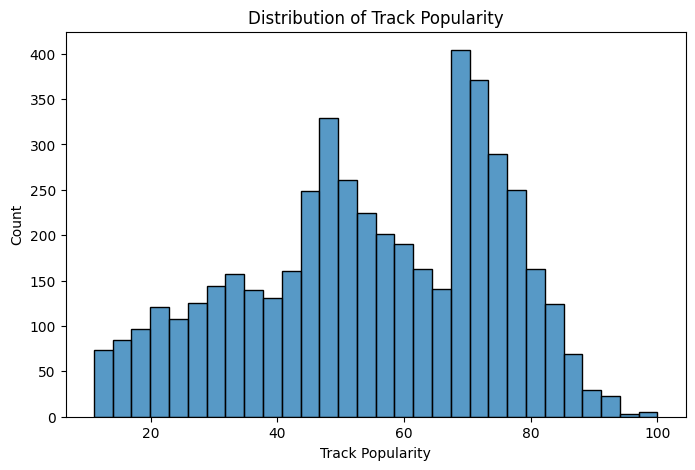

In [20]:
# EDA Raw Popularity Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df["track_popularity"], bins=30)
plt.title("Distribution of Track Popularity")
plt.xlabel("Track Popularity")
plt.ylabel("Count")
plt.show()

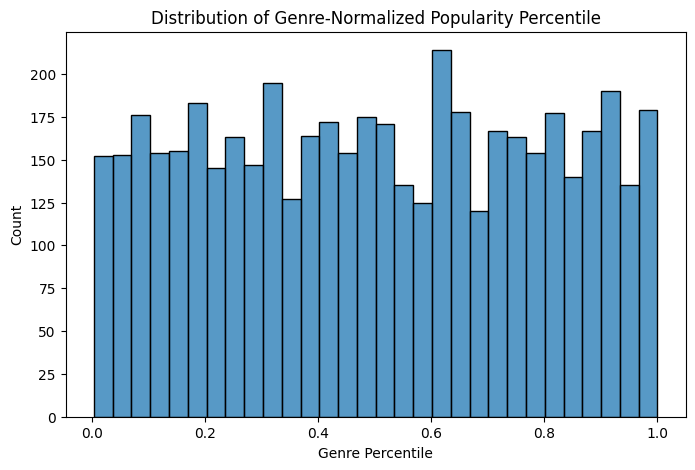

In [21]:
# EDA Genre-normalized target distribution

plt.figure(figsize=(8, 5))
sns.histplot(df["genre_percentile"], bins=30)
plt.title("Distribution of Genre-Normalized Popularity Percentile")
plt.xlabel("Genre Percentile")
plt.ylabel("Count")
plt.show()

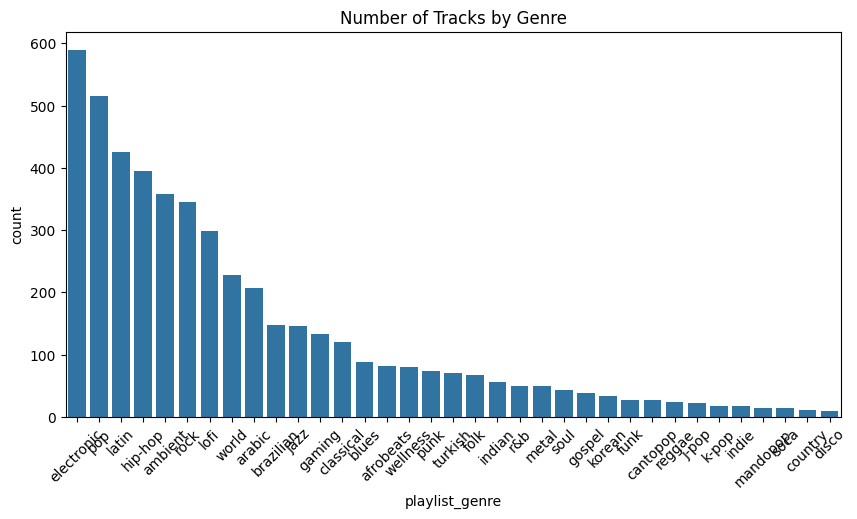

In [22]:
# EDA Genre counts

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="playlist_genre", order=df["playlist_genre"].value_counts().index)
plt.title("Number of Tracks by Genre")
plt.xticks(rotation=45)
plt.show()

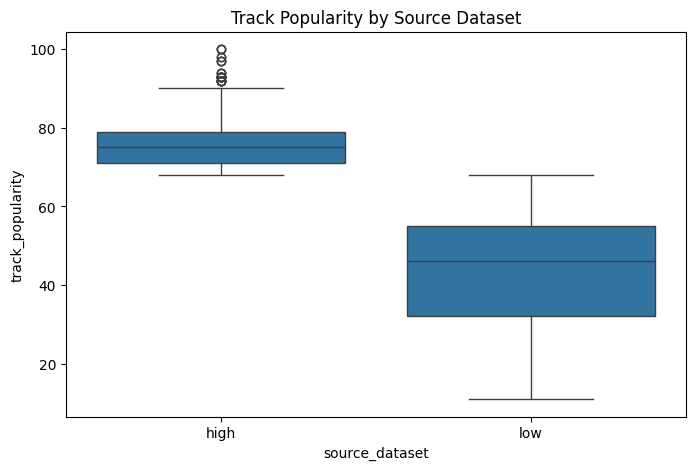

In [23]:
# EDA Compare high vs low source datasets

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="source_dataset", y="track_popularity")
plt.title("Track Popularity by Source Dataset")
plt.show()

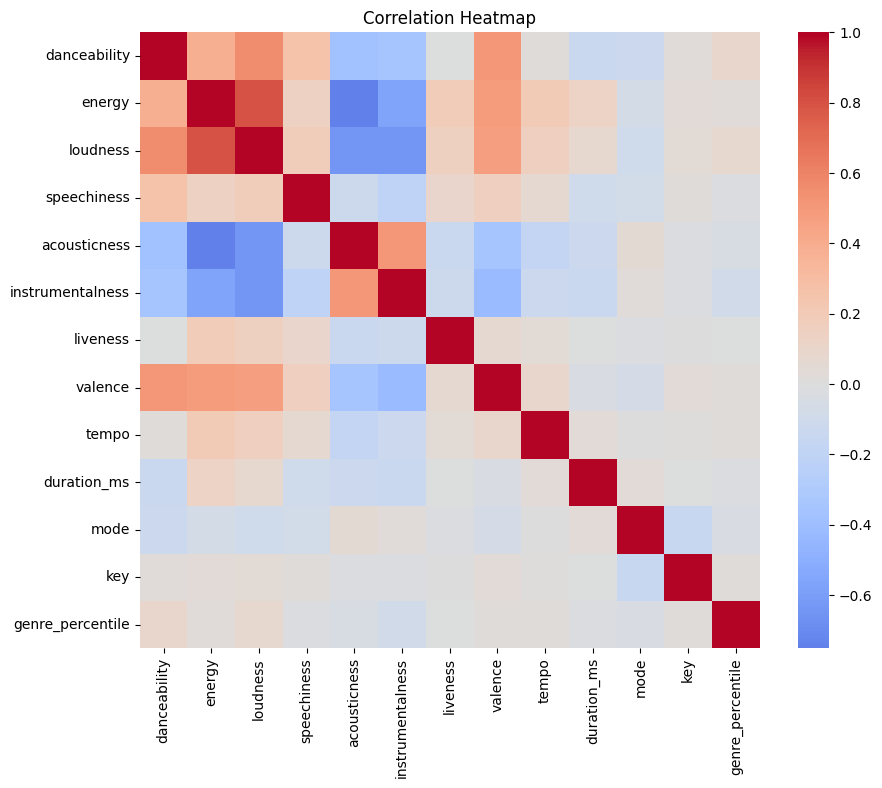

In [24]:
# EDA Correlation heatmap

plt.figure(figsize=(10, 8))
corr = df[features + ["genre_percentile"]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

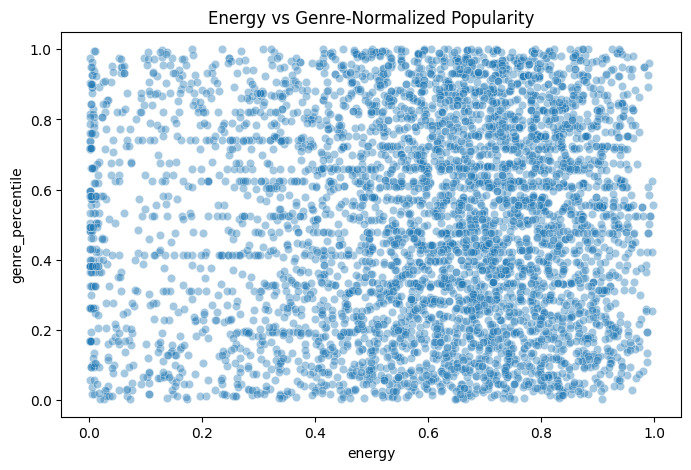

In [25]:
# EDA example scatter plot

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="energy", y="genre_percentile", alpha=0.4)
plt.title("Energy vs Genre-Normalized Popularity")
plt.show()

In [26]:
# EDA Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Scale only for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3622, 12)
Test shape: (1208, 12)


In [27]:
# Model 1 - Linear Regression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr) 
r2_lr = r2_score(y_test, y_pred_lr)
spearman_lr = spearmanr(y_test, y_pred_lr).correlation

print('Linear Regression Results:')
print(f'RMSE: {rmse_lr:.4f}')
print(f'MAE: {mae_lr:.4f}')
print(f'R2: {r2_lr:.4f}')       
print(f'Spearman Correlation: {spearman_lr:.4f}')

Linear Regression Results:
RMSE: 0.2823
MAE: 0.2427
R2: 0.0261
Spearman Correlation: 0.1599


In [28]:
# Model 2 - Ridge Regression

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
spearman_ridge = spearmanr(y_test, y_pred_ridge).correlation

print('Ridge Regression Results:')
print(f'RMSE: {rmse_ridge:.4f}')
print(f'MAE: {mae_ridge:.4f}')
print(f'R2: {r2_ridge:.4f}')
print(f'Spearman Correlation: {spearman_ridge:.4f}')    

Ridge Regression Results:
RMSE: 0.2823
MAE: 0.2427
R2: 0.0261
Spearman Correlation: 0.1599


In [29]:
# Model 3 - Random Forest Regressor

rf = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
spearman_rf = spearmanr(y_test, y_pred_rf).correlation

print("Random Forest Results")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R^2:", r2_rf)
print("Spearman:", spearman_rf)

Random Forest Results
RMSE: 0.2561200923135944
MAE: 0.21364114767888354
R^2: 0.1983681833306149
Spearman: 0.4192853143499689


In [30]:
# Cross-validation

ridge_cv = cross_val_score(Ridge(alpha=1.0), scaler.fit_transform(X), y, cv=5, scoring="r2")
print("Ridge CV R^2 scores:", ridge_cv)
print("Average Ridge CV R^2:", ridge_cv.mean())

rf_cv = cross_val_score(
    RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    X, y, cv=5, scoring="r2"
)
print("Random Forest CV R^2 scores:", rf_cv)
print("Average Random Forest CV R^2:", rf_cv.mean())

Ridge CV R^2 scores: [-1.88688076 -0.77850867 -0.57860923 -0.27479802 -0.680293  ]
Average Ridge CV R^2: -0.8398179393391059
Random Forest CV R^2 scores: [-1.64249904 -0.65781305 -0.62947544 -0.14941752 -0.64509924]
Average Random Forest CV R^2: -0.7448608608584095


In [31]:
# Model Comparisons

results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Random Forest"],
    "RMSE": [rmse_lr, rmse_ridge, rmse_rf],
    "MAE": [mae_lr, mae_ridge, mae_rf],
    "R2": [r2_lr, r2_ridge, r2_rf],
    "Spearman": [spearman_lr, spearman_ridge, spearman_rf]
})

print(results)

               Model      RMSE       MAE        R2  Spearman
0  Linear Regression  0.282305  0.242727  0.026076  0.159899
1   Ridge Regression  0.282306  0.242728  0.026070  0.159902
2      Random Forest  0.256120  0.213641  0.198368  0.419285


In [32]:
# Feature importance and coefficient interpretations for linear and ridge models

coef_df = pd.DataFrame({
    "Feature": features,
    "Linear_Coefficient": lr.coef_,
    "Ridge_Coefficient": ridge.coef_
}).sort_values("Ridge_Coefficient", key=np.abs, ascending=False)

print(coef_df)

             Feature  Linear_Coefficient  Ridge_Coefficient
5   instrumentalness           -0.030920          -0.030904
0       danceability            0.027666           0.027654
1             energy           -0.020313          -0.020291
3        speechiness           -0.016228          -0.016220
7            valence           -0.015164          -0.015153
2           loudness            0.011220           0.011213
9        duration_ms           -0.007728          -0.007726
8              tempo            0.005811           0.005808
10              mode           -0.004674          -0.004672
11               key            0.003290           0.003289
6           liveness           -0.002989          -0.002990
4       acousticness            0.000132           0.000135


             Feature  Importance
2           loudness    0.112587
9        duration_ms    0.103263
0       danceability    0.100631
1             energy    0.100584
8              tempo    0.094313
4       acousticness    0.093826
3        speechiness    0.092855
7            valence    0.092414
6           liveness    0.084001
5   instrumentalness    0.068479
11               key    0.046393
10              mode    0.010654


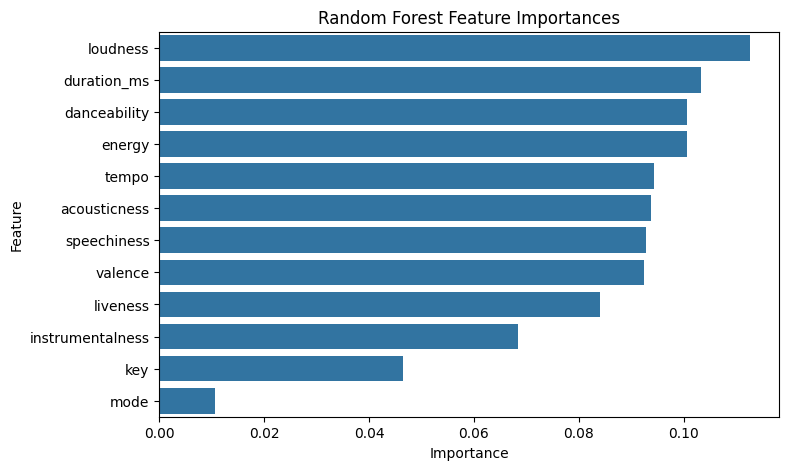

In [33]:
# For random forest

rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(rf_importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=rf_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importances")
plt.show()